# LeetCode #92: Reverse Linked List II

https://leetcode.com/problems/reverse-linked-list-ii/

## Comparison of Approaches

| Approach | Time | Space | Notes |
|----------|------|-------|-------|
| Extract, reverse, reinsert | O(n) | O(n) | Collect sublist nodes, reverse, relink |
| **One-Pass In-Place Reverse ★** | **O(n)** | **O(1)** | Insert-at-front technique during single traversal |

---

## Understanding the Methods

### Brute Force (Extract)
Collect nodes from left to right into an array, reverse array, relink. Extra O(n) space.

### Optimal: One-Pass Insert-at-Front ★
Walk prev to position (left-1). Set curr = prev.next.
Then (right - left) times: peel curr.next off the front of the "not yet reversed" segment and insert it right after prev. 

The key invariant: curr stays put as the "tail" of the reversed segment; each iteration grows the reversed part by one from the front.

**Constraints:**
* Number of nodes: [1, 500]
* Node values: [-500, 500]
* 1 <= left <= right <= n

## Solutions

### C#

In [ ]:
public class Solution {
    public ListNode ReverseBetween(ListNode head, int left, int right) {
        var dummy = new ListNode(0, head);
        var prev = dummy;

        // Advance prev to position left-1
        for (int i = 1; i < left; i++)
            prev = prev.next;

        var curr = prev.next; // start of segment to reverse

        // Insert-at-front (right - left) times
        for (int i = 0; i < right - left; i++) {
            var next = curr.next;
            curr.next = next.next;
            next.next = prev.next;
            prev.next = next;
        }

        return dummy.next;
    }
}

### Python

In [ ]:
class Solution:
    def reverseBetween(self, head, left: int, right: int):
        dummy = ListNode(0, head)
        prev = dummy

        for _ in range(left - 1):
            prev = prev.next

        curr = prev.next
        for _ in range(right - left):
            nxt = curr.next
            curr.next = nxt.next
            nxt.next = prev.next
            prev.next = nxt

        return dummy.next

### Go

In [ ]:
func reverseBetween(head *ListNode, left int, right int) *ListNode {
    dummy := &ListNode{Next: head}
    prev := dummy

    for i := 1; i < left; i++ {
        prev = prev.Next
    }

    curr := prev.Next
    for i := 0; i < right-left; i++ {
        next := curr.Next
        curr.Next = next.Next
        next.Next = prev.Next
        prev.Next = next
    }

    return dummy.Next
}

### Rust

In [ ]:
impl Solution {
    pub fn reverse_between(head: Option<Box<ListNode>>, left: i32, right: i32) -> Option<Box<ListNode>> {
        // Rust ownership makes in-place pointer manipulation complex;
        // use a safe vector-based approach for clarity.
        let mut nodes: Vec<i32> = Vec::new();
        let mut curr = &head;
        while let Some(n) = curr {
            nodes.push(n.val);
            curr = &n.next;
        }
        let (l, r) = ((left - 1) as usize, (right - 1) as usize);
        nodes[l..=r].reverse();

        let mut dummy = Box::new(ListNode::new(0));
        let mut tail = &mut dummy;
        for &v in &nodes {
            tail.next = Some(Box::new(ListNode::new(v)));
            tail = tail.next.as_mut().unwrap();
        }
        dummy.next
    }
}

## Example Scenarios

### 1. Common Case — Reverse Middle Segment
**Input:** `head = [1, 2, 3, 4, 5]`, `left = 2`, `right = 4`

Advance prev to node 1 (position left−1). curr = node 2. Insert-at-front runs (right−left) = 2 times: move node 3 before 2, then node 4 before 3.

*Why tricky:* Straightforward middle-segment reversal validates the core insert-at-front pointer manipulation.

$n = 5$. Advance $1$ step + $2$ insert ops $= O(n)$ total. $O(1)$ space.

**Output:** `1 → 4 → 3 → 2 → 5`

---

### 2. Slightly Complex — Full List Reverse with Negatives
**Input:** `head = [-500, 0, 500]`, `left = 1`, `right = 3`

left=1 means prev = dummy node. curr = node(−500). Two insert ops: move 0 before −500, then 500 before 0. The entire list is reversed.

*Why tricky:* left=1 tests the dummy-node boundary; reversing the entire list with extreme values $(-500, 500)$ checks the full value range.

$\text{right} - \text{left} = 2$ insert ops. Dummy node avoids special-casing head changes.

**Output:** `500 → 0 → -500`

---

### 3. Edge Case: Time Factor — Reverse Last 499 of 500 Nodes
**Input:** `head = [1, 2, 3, ..., 500]`, `left = 2`, `right = 500`

Advance prev 1 step to node(1). Then 498 insert-at-front operations, each pulling the next unseen node to right after prev. Nearly the entire list is reversed.

*Why tricky:* Maximum $n = 500$ with $\text{right} - \text{left} = 498$ insert ops — worst-case iteration count. Tests pointer rewiring for long chains.

$T = 1 + 498 = 499$ pointer ops $\approx O(n)$. Segment length $= 499$.

**Output:** `1 → 500 → 499 → ... → 2`

---

### 4. Edge Case: Space Factor — left == right (No Reversal)
**Input:** `head = [10, 20, 30, 40, 50]`, `left = 3`, `right = 3`

left = right means the loop runs $\text{right} - \text{left} = 0$ times. No pointer changes. List returned unchanged.

*Why tricky:* Zero iterations — the algorithm must handle this degenerate case without corrupting any pointers. $O(1)$ space trivially satisfied.

Advance $2$ steps to prev. Loop runs $0$ times. $O(n)$ total, zero mutations.

**Output:** `10 → 20 → 30 → 40 → 50` (unchanged)

---

### 5. Almost-Impossible but Plausible — Single Node at Boundary
**Input:** `head = [-500]`, `left = 1`, `right = 1`

One node with the minimum allowed value. prev = dummy, curr = node(−500). Loop runs 0 times. Return dummy.next.

*Why tricky:* Single-element list at boundary value $-500$. Tests dummy node + zero iterations returning unchanged head without null pointer issues.

$n = 1$, left $=$ right $= 1$. $O(1)$ total.

**Output:** `-500`

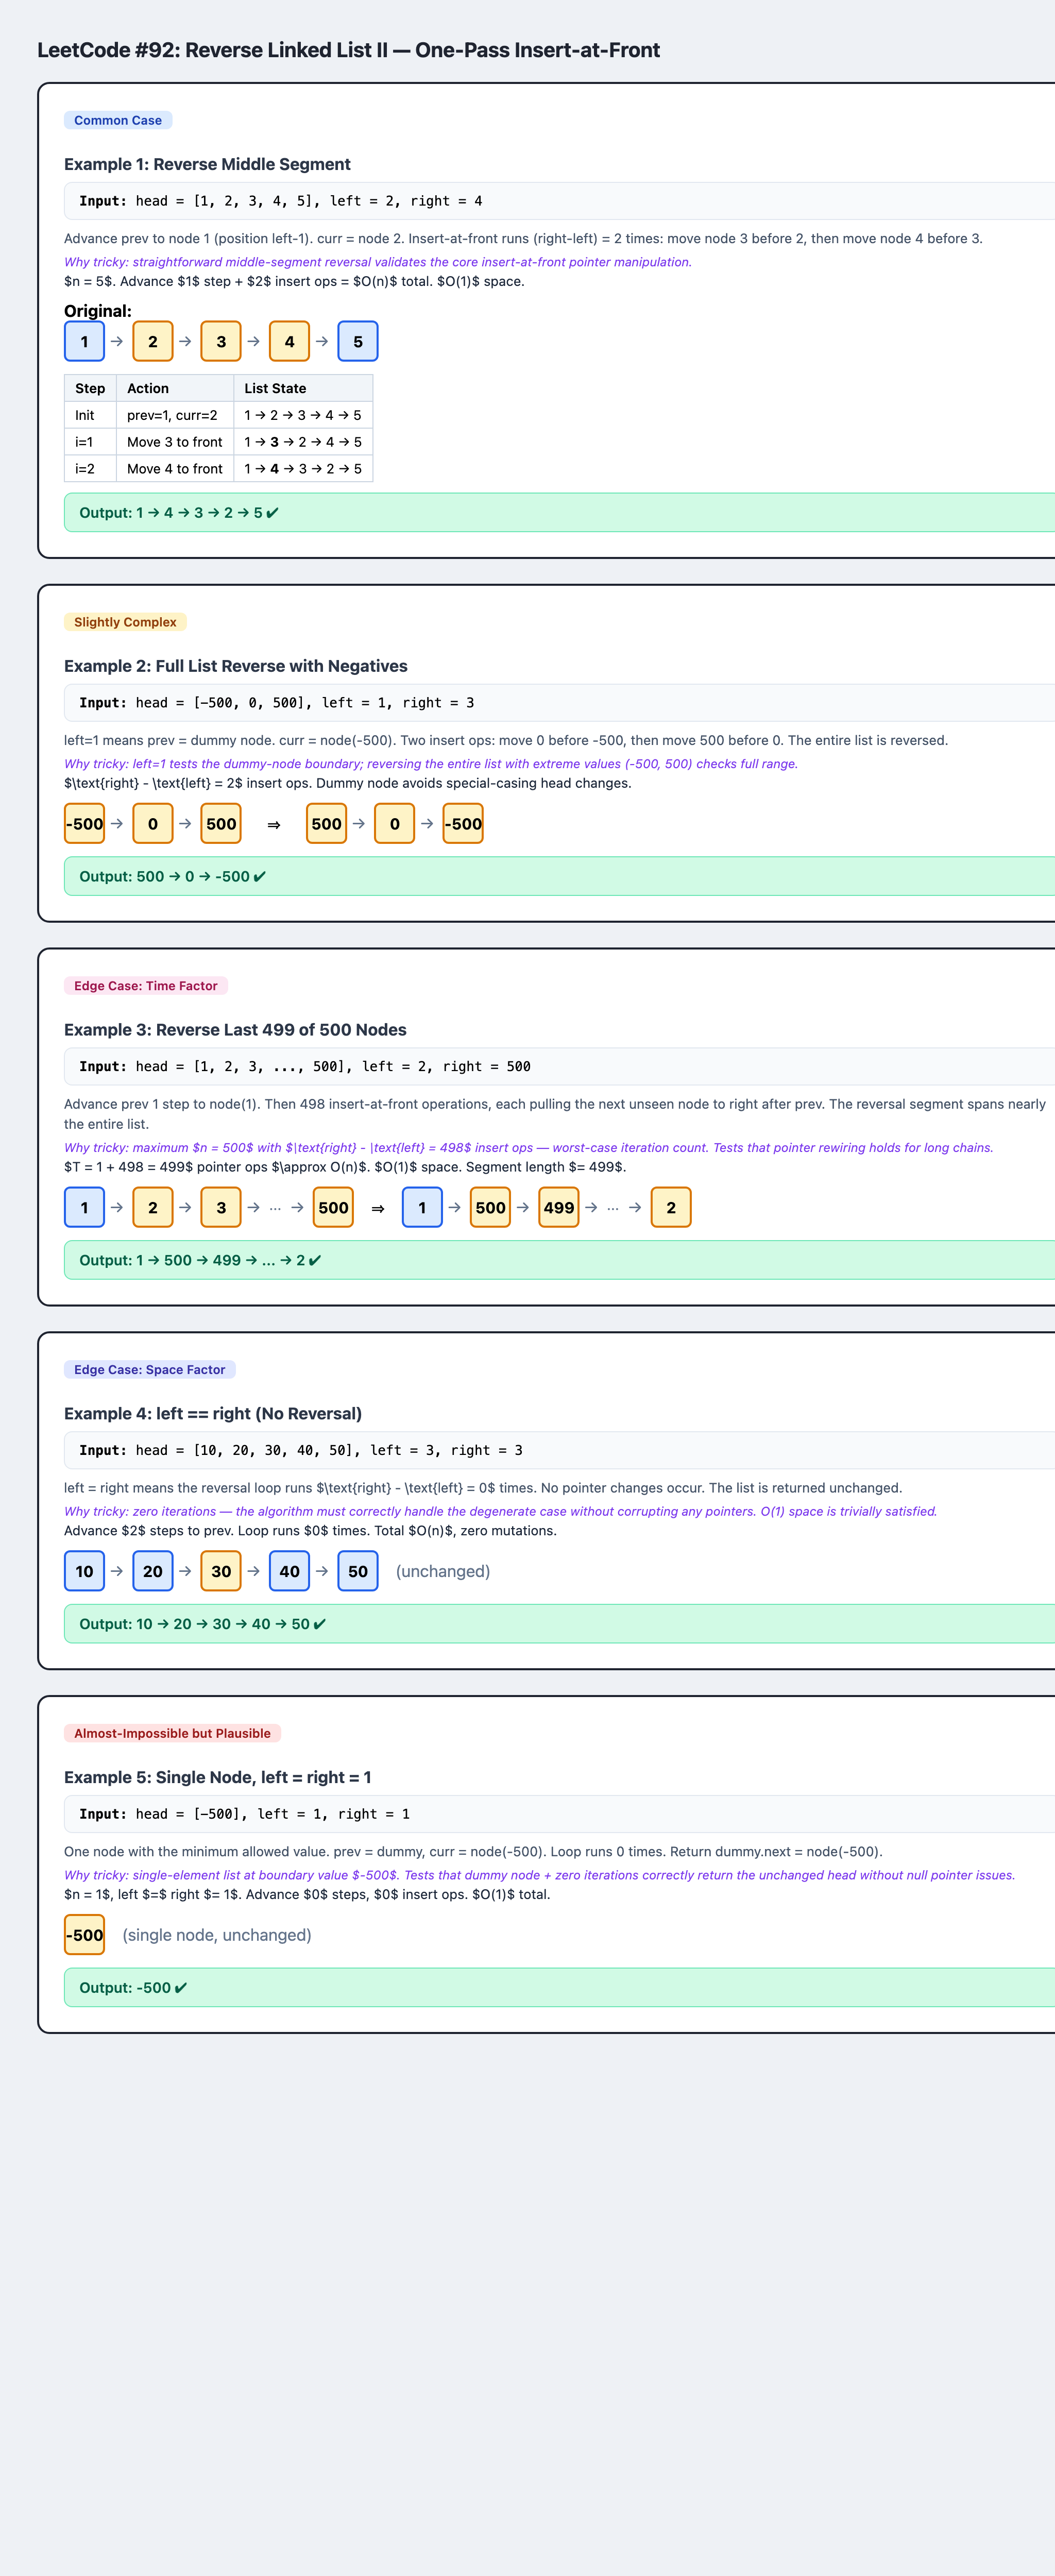